# Clothing Similarity Embedding — MobileNetV4 (Improved)

Improvements over the baseline notebook:
- **GELU activations** replacing every ReLU in the MobileNetV4 backbone
- **Projection head** (non-linear, 2-layer) between backbone features and the final L2-normalized embedding — improves embedding quality over a single linear layer
- **Auxiliary classification head** trained jointly, enabling **CutMix / MixUp** augmentation (applied only to the classification branch — the metric/triplet branch receives clean images, since mixing breaks the identity assumption triplet loss depends on)
- **MPerClassSampler** guarantees M=4 samples per class per batch, so batch-hard triplet mining always has valid positives
- **Semihard triplet mining** via `pytorch-metric-learning`
- **Joint loss**: `triplet_loss + λ * cls_loss` where CutMix/MixUp soft labels feed the cls branch
- Evaluation: **P@1, P@5, P@10, mAP, cls_accuracy** on the held-out test split
- **t-SNE** visualization of test embeddings with proper class-name legend


## 1. Install & Imports


In [1]:
!pip install pytorch-metric-learning timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 5.4 MB/s eta 0:00:00


In [2]:
import os, random, math, time, shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from tqdm.auto import tqdm

from pytorch_metric_learning.samplers import MPerClassSampler
from pytorch_metric_learning import miners, losses

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## 2. Configuration

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_ROOT  = Path("/kaggle/input/datasets/afqwe0/clotheslabelled")
WORK_DIR   = Path("/kaggle/working")
CKPT_PATH  = WORK_DIR / "mobilenetv4_best.pth"

# ── Model ───────────────────────────────────────────────────────────────────
BACKBONE_NAME  = "mobilenetv4_conv_large.e500_r256_in1k"
BACKBONE_DIM   = 1280          # output feature dim of this backbone
EMBED_DIM      = 128           # final L2-normalized embedding dimension
NUM_CLASSES    = 25

# ── Training ────────────────────────────────────────────────────────────────
IMG_SIZE       = 224
BATCH_SIZE     = 32
M_PER_CLASS    = 4             # MPerClassSampler: 4 images per class per batch
EPOCHS         = 30
LR             = 1e-4
WEIGHT_DECAY   = 1e-4

# ── Triplet ─────────────────────────────────────────────────────────────────
TRIPLET_MARGIN = 0.4

# ── CutMix / MixUp (classification branch only) ─────────────────────────────
MIX_PROB       = 0.5
MIXUP_ALPHA    = 0.2
CUTMIX_ALPHA   = 1.0

# ── Joint loss weight ────────────────────────────────────────────────────────
LAMBDA_CLS     = 0.5           # total = triplet_loss + LAMBDA_CLS * cls_loss


## 3. Class Definitions


In [4]:
CLASS_NAMES = {
    0:  "t_shirt",
    1:  "trousers",
    2:  "blazer",
    3:  "hoodie",
    4:  "sneakers",
    5:  "dolphin_shorts",
    6:  "denim_shorts_(jorts)",
    7:  "fit_and_flare_dress",
    8:  "jacket",
    9:  "skirt",
    10: "men_suits_western_coatpant",
    11: "loafers",
    12: "formal_pants_shirt_set",
    13: "dhaka_topi",
    14: "sari",
    15: "baggy_pants",
    16: "jeans_pants",
    17: "one_piece",
    18: "sweatshirt",
    19: "caps",
    20: "cardigan",
    21: "cowl_neck_top",
    22: "turtleneck",
    23: "polo",
    24: "sweater",
}
assert len(CLASS_NAMES) == NUM_CLASSES


## 4. Data Loading and Augmentation

In [5]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


In [6]:
class ClothingDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


def collect_samples(root_dir):
    """Walk person_folder/class_folder structure, assign integer labels per class."""
    samples = []
    label_to_idx = {}
    current_label = 0

    for top_folder in sorted(os.listdir(root_dir)):
        top_path = os.path.join(root_dir, top_folder)
        if not os.path.isdir(top_path):
            continue
        for class_name in sorted(os.listdir(top_path)):
            class_path = os.path.join(top_path, class_name)
            if not os.path.isdir(class_path):
                continue
            # Use class_name only (not top_folder) so the same class across
            # different person folders maps to the same label id
            if class_name not in label_to_idx:
                label_to_idx[class_name] = current_label
                current_label += 1
            label = label_to_idx[class_name]
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith((".jpg", ".jpeg", ".png")):
                    samples.append((os.path.join(class_path, img_name), label))

    print(f"Total images: {len(samples)} across {current_label} classes")
    return samples, label_to_idx


all_samples, label_to_idx = collect_samples(DATA_ROOT)


Total images: 2860 across 25 classes


In [7]:
# ── Per-class stratified 70 / 15 / 15 split ─────────────────────────────────
class_samples = defaultdict(list)
for path, label in all_samples:
    class_samples[label].append((path, label))

train_samples, val_samples, test_samples = [], [], []

for label, images in class_samples.items():
    train, temp = train_test_split(images, test_size=0.30, random_state=SEED)
    val, test   = train_test_split(temp,   test_size=0.50, random_state=SEED)
    train_samples.extend(train)
    val_samples.extend(val)
    test_samples.extend(test)

print(f"Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}")

train_dataset = ClothingDataset(train_samples, train_tf)
val_dataset   = ClothingDataset(val_samples,   eval_tf)
test_dataset  = ClothingDataset(test_samples,  eval_tf)


Train: 1991 | Val: 428 | Test: 441


In [8]:
# ── MPerClassSampler: guarantees M=4 samples per class per batch ─────────────
# This is critical for semihard triplet mining with small datasets —
# without it, many batches would have zero valid positive pairs for some classes.
train_labels = [s[1] for s in train_samples]

train_sampler = MPerClassSampler(
    train_labels,
    m=M_PER_CLASS,
    batch_size=BATCH_SIZE,
    length_before_new_iter=len(train_dataset),
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,         num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,         num_workers=0)

print("Loaders ready.")


Loaders ready.


## 5. CutMix / MixUp

Applied **only to the classification branch** — the triplet branch always receives clean, un-mixed images so the identity assumption (anchor/positive/negative each represent one coherent class) is never violated.


In [9]:
def rand_bbox(size, lam):
    W, H = size[3], size[2]
    cut_rat = math.sqrt(1.0 - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    return x1, y1, x2, y2


def apply_mixup_cutmix(images, labels, num_classes, prob=MIX_PROB):
    """Returns (mixed_images, labels_a_onehot, labels_b_onehot, lam)."""
    labels_oh = F.one_hot(labels, num_classes).float()
    if np.random.rand() > prob:
        return images, labels_oh, labels_oh, 1.0

    perm = torch.randperm(images.size(0), device=images.device)
    use_cutmix = np.random.rand() < 0.5

    if use_cutmix:
        lam = np.random.beta(CUTMIX_ALPHA, CUTMIX_ALPHA)
        x1, y1, x2, y2 = rand_bbox(images.size(), lam)
        images[:, :, y1:y2, x1:x2] = images[perm, :, y1:y2, x1:x2]
        lam = 1.0 - ((x2 - x1) * (y2 - y1) / (images.size(-1) * images.size(-2)))
    else:
        lam = np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA)
        images = lam * images + (1.0 - lam) * images[perm]

    return images, labels_oh, labels_oh[perm], lam


def soft_ce_loss(logits, labels_a, labels_b, lam):
    log_probs = F.log_softmax(logits, dim=1)
    loss_a = -(labels_a * log_probs).sum(dim=1)
    loss_b = -(labels_b * log_probs).sum(dim=1)
    return (lam * loss_a + (1.0 - lam) * loss_b).mean()


## 6. Model: MobileNetV4 + GELU + Projection Head + Classification Head

- **Backbone**: `mobilenetv4_conv_large` from timm, pretrained on ImageNet-1k
- **GELU swap**: every `nn.ReLU` in the backbone replaced recursively with `nn.GELU`
- **Projection head**: 2-layer nonlinear MLP → L2-normalized embedding (used for triplet loss)
- **Classification head**: separate branch → 25-way logits (used for CutMix/MixUp auxiliary loss)

The projection head improves metric learning quality over a single linear layer because the intermediate nonlinearity lets the head learn a better mapping from backbone features to the metric space, without distorting the backbone's learned representations.


In [10]:
def replace_relu_with_gelu(module):
    """Recursively replace every nn.ReLU in a module with nn.GELU."""
    for name, child in module.named_children():
        if isinstance(child, nn.ReLU):
            setattr(module, name, nn.GELU())
        else:
            replace_relu_with_gelu(child)
    return module


class MobileNetV4Embedding(nn.Module):
    def __init__(self, backbone_name=BACKBONE_NAME, backbone_dim=BACKBONE_DIM,
                 embed_dim=EMBED_DIM, num_classes=NUM_CLASSES):
        super().__init__()

        backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        backbone = replace_relu_with_gelu(backbone)
        self.backbone = backbone

        # Non-linear projection head → metric embedding
        self.projection_head = nn.Sequential(
            nn.Linear(backbone_dim, backbone_dim),
            nn.GELU(),
            nn.Linear(backbone_dim, embed_dim),
        )

        # Classification head → auxiliary CutMix/MixUp loss
        self.classification_head = nn.Sequential(
            nn.Linear(backbone_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x, return_logits=False):
        feats = self.backbone(x)
        embedding = F.normalize(self.projection_head(feats), p=2, dim=1)
        if return_logits:
            logits = self.classification_head(feats)
            return embedding, logits
        return embedding


# Quick shape check
_m = MobileNetV4Embedding().to(DEVICE)
relu_count = sum(1 for mod in _m.modules() if isinstance(mod, nn.ReLU))
gelu_count = sum(1 for mod in _m.modules() if isinstance(mod, nn.GELU))
print(f"ReLU remaining: {relu_count} | GELU count: {gelu_count}")

_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
_emb, _logits = _m(_x, return_logits=True)
print(f"Embedding shape: {_emb.shape} | Logits shape: {_logits.shape}")
print(f"Embedding norms (should be 1.0): {_emb.norm(dim=1)}")
del _m, _x, _emb, _logits
torch.cuda.empty_cache()


model.safetensors:   0%|          | 0.00/131M [00:00<?, ?B/s]

ReLU remaining: 0 | GELU count: 51
Embedding shape: torch.Size([2, 128]) | Logits shape: torch.Size([2, 25])
Embedding norms (should be 1.0): tensor([1., 1.], device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)


## 7. Training Setup

In [11]:
model = MobileNetV4Embedding().to(DEVICE)

miner     = miners.TripletMarginMiner(margin=TRIPLET_MARGIN, type_of_triplets="semihard")
loss_func = losses.TripletMarginLoss(margin=TRIPLET_MARGIN)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


## 8. Train and Validation Functions

In [12]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_trip, total_cls, total_loss, n_batches = 0.0, 0.0, 0.0, 0

    pbar = tqdm(loader, desc="  Train", leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        # ── Triplet branch: clean images ──────────────────────────────────────
        embeddings = model(images, return_logits=False)
        hard_triplets = miner(embeddings, labels)
        t_loss = loss_func(embeddings, labels, hard_triplets)

        # ── Classification branch: mixed images ───────────────────────────────
        mixed_images = images.clone()
        mixed_images, labels_a, labels_b, lam = apply_mixup_cutmix(mixed_images, labels, NUM_CLASSES)
        _, mixed_logits = model(mixed_images, return_logits=True)
        c_loss = soft_ce_loss(mixed_logits, labels_a, labels_b, lam)

        loss = t_loss + LAMBDA_CLS * c_loss
        loss.backward()
        optimizer.step()

        total_trip  += t_loss.item()
        total_cls   += c_loss.item()
        total_loss  += loss.item()
        n_batches   += 1

        pbar.set_postfix(triplet=f"{t_loss.item():.4f}", cls=f"{c_loss.item():.4f}")

    return total_loss / n_batches, total_trip / n_batches, total_cls / n_batches


@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss, n_batches = 0.0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        embeddings = model(images, return_logits=False)
        hard_triplets = miner(embeddings, labels)
        loss = loss_func(embeddings, labels, hard_triplets)
        total_loss += loss.item()
        n_batches  += 1

    return total_loss / max(n_batches, 1)


## 9. Training Loop

In [13]:
history = {"train_loss": [], "train_trip": [], "train_cls": [], "val_loss": []}
best_val_loss = float("inf")

epoch_pbar = tqdm(range(EPOCHS), desc="Epochs")
for epoch in epoch_pbar:
    t0 = time.time()

    tr_loss, tr_trip, tr_cls = train_one_epoch(model, train_loader, optimizer)
    val_loss = validate(model, val_loader)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_trip"].append(tr_trip)
    history["train_cls"].append(tr_cls)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CKPT_PATH)

    epoch_pbar.set_postfix(
        train=f"{tr_loss:.4f}", val=f"{val_loss:.4f}", best=f"{best_val_loss:.4f}"
    )

print(f"\nBest val triplet loss: {best_val_loss:.4f} → saved to {CKPT_PATH}")


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

  Train:   0%|          | 0/62 [00:00<?, ?it/s]

  Train:   0%|          | 0/62 [00:00<?, ?it/s]

  Train:   0%|          | 0/62 [00:00<?, ?it/s]

  Train:   0%|          | 0/62 [00:00<?, ?it/s]

...

  Train:   0%|          | 0/62 [00:00<?, ?it/s]

  Train:   0%|          | 0/62 [00:00<?, ?it/s]

  Train:   0%|          | 0/62 [00:00<?, ?it/s]

  Train:   0%|          | 0/62 [00:00<?, ?it/s]


Best val triplet loss: 0.1303 → saved to /kaggle/working/mobilenetv4_best.pth


## 10. Training Curve

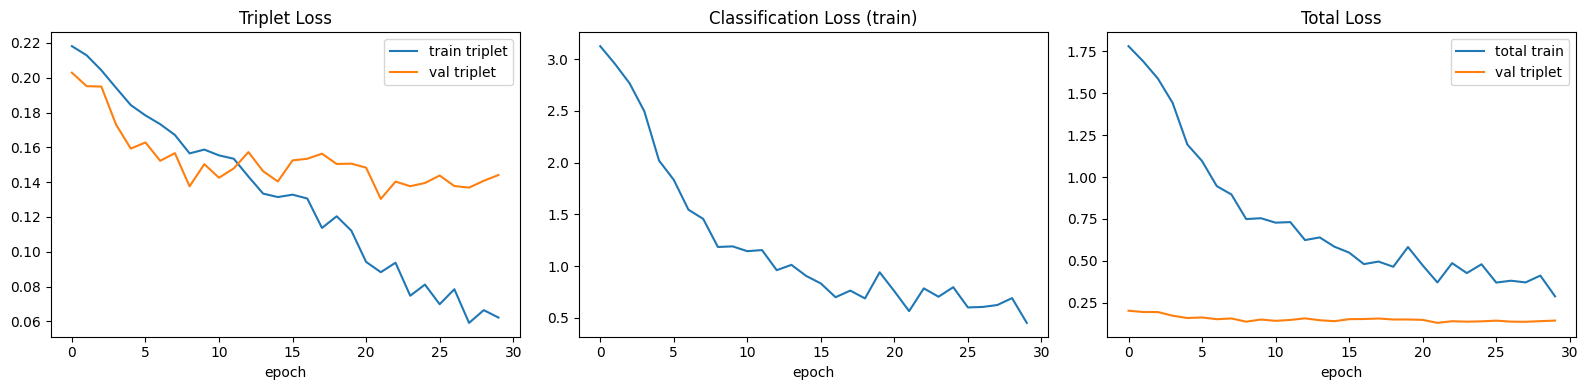

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["train_trip"], label="train triplet")
axes[0].plot(history["val_loss"],   label="val triplet")
axes[0].set_title("Triplet Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history["train_cls"])
axes[1].set_title("Classification Loss (train)"); axes[1].set_xlabel("epoch")

axes[2].plot(history["train_loss"], label="total train")
axes[2].plot(history["val_loss"],   label="val triplet")
axes[2].set_title("Total Loss"); axes[2].set_xlabel("epoch"); axes[2].legend()

plt.tight_layout()
plt.show()


## 11. Evaluation on Test Split

Metrics:
- **P@K** (K=1,5,10): fraction of top-K nearest neighbors sharing the query's class
- **mAP**: mean Average Precision across the full ranked list
- **cls_accuracy**: classification accuracy from the auxiliary head


In [15]:
@torch.no_grad()
def extract_embeddings(model, loader):
    model.eval()
    all_emb, all_labels, all_logits = [], [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        emb, logits = model(images, return_logits=True)
        all_emb.append(emb.cpu())
        all_labels.append(labels)
        all_logits.append(logits.cpu())
    return torch.cat(all_emb), torch.cat(all_labels), torch.cat(all_logits)


def precision_at_k(embeddings, labels, k_values=(1, 5, 10)):
    sim = embeddings @ embeddings.t()
    sim.fill_diagonal_(float("-inf"))
    results = {}
    for k in k_values:
        topk_labels = labels[sim.topk(k, dim=1).indices]   # (N, k)
        correct = (topk_labels == labels.unsqueeze(1)).float()
        results[f"P@{k}"] = correct.mean().item()
    return results


def mean_average_precision(embeddings, labels):
    sim = embeddings @ embeddings.t()
    sim.fill_diagonal_(float("-inf"))
    ranking = sim.argsort(dim=1, descending=True)
    aps = []
    for i in range(sim.size(0)):
        ranked_labels = labels[ranking[i]]
        relevant = (ranked_labels == labels[i]).float()
        if relevant.sum() == 0:
            continue
        cum_rel = torch.cumsum(relevant, dim=0)
        prec_at_each = cum_rel / torch.arange(1, len(relevant) + 1, dtype=torch.float32)
        ap = (prec_at_each * relevant).sum() / relevant.sum()
        aps.append(ap.item())
    return float(np.mean(aps))


In [16]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

test_emb, test_labels, test_logits = extract_embeddings(model, test_loader)

cls_acc  = (test_logits.argmax(dim=1) == test_labels).float().mean().item()
p_at_k   = precision_at_k(test_emb, test_labels)
map_score = mean_average_precision(test_emb, test_labels)

print("=" * 40)
print(f"  P@1  : {p_at_k['P@1']:.4f}")
print(f"  P@5  : {p_at_k['P@5']:.4f}")
print(f"  P@10 : {p_at_k['P@10']:.4f}")
print(f"  mAP  : {map_score:.4f}")
print(f"  cls_accuracy : {cls_acc:.4f}")
print("=" * 40)


  P@1  : 0.8322
  P@5  : 0.8236
  P@10 : 0.8088
  mAP  : 0.7502
  cls_accuracy : 0.8730


## 12. t-SNE Visualization

/tmp/ipykernel_58/1278708472.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", NUM_CLASSES)


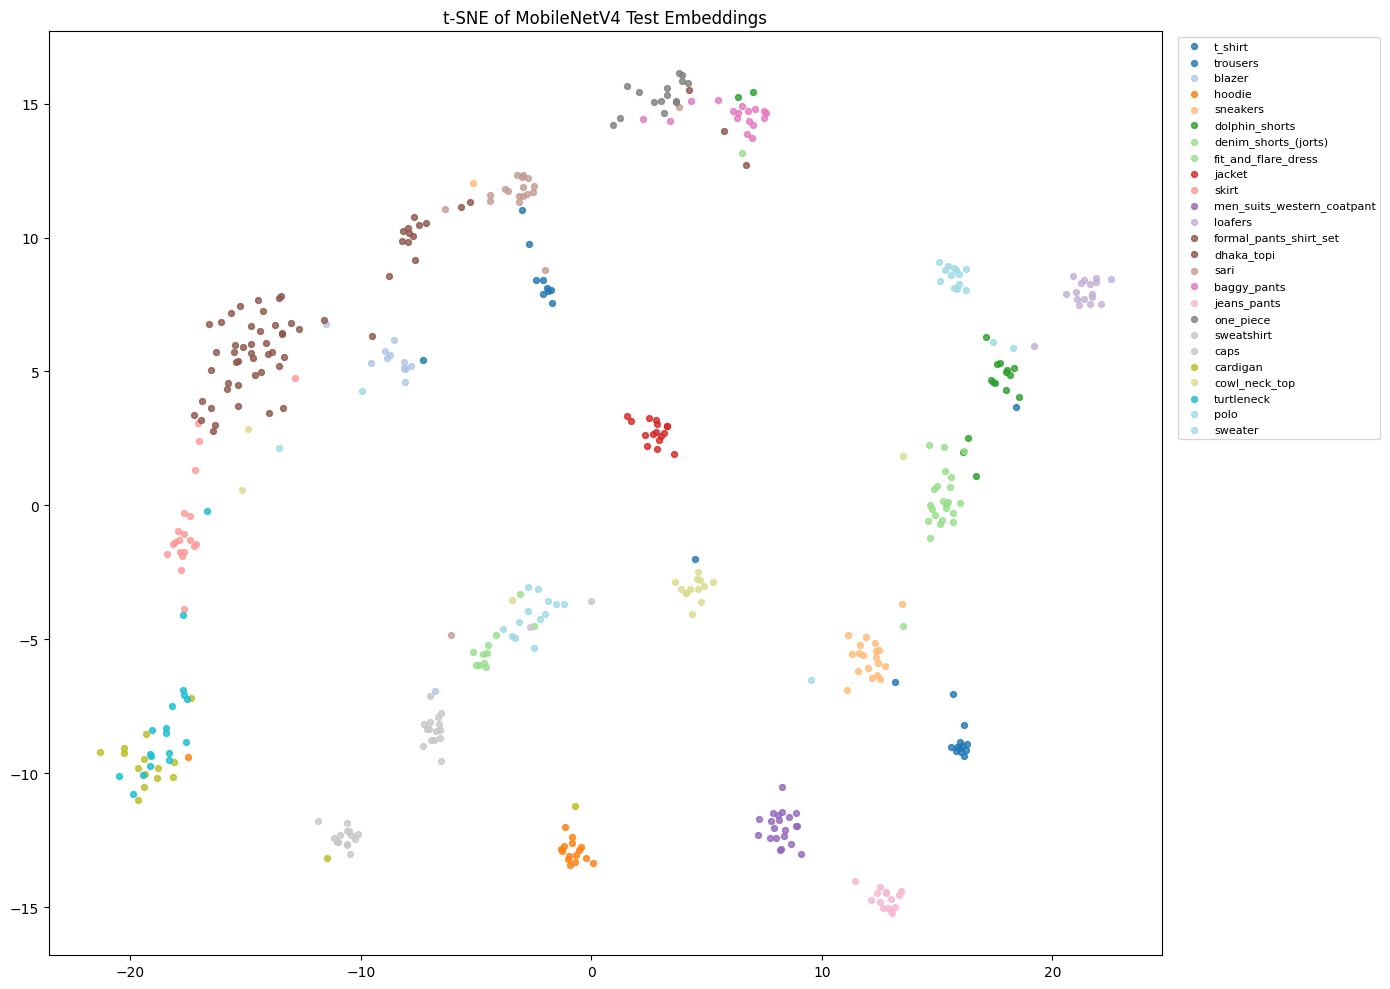

In [17]:
tsne   = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca")
proj   = tsne.fit_transform(test_emb.numpy())
labels_np = test_labels.numpy()

fig, ax = plt.subplots(figsize=(14, 10))
cmap = plt.cm.get_cmap("tab20", NUM_CLASSES)

for cls_id in range(NUM_CLASSES):
    mask = labels_np == cls_id
    ax.scatter(proj[mask, 0], proj[mask, 1],
               color=cmap(cls_id), label=CLASS_NAMES[cls_id], s=18, alpha=0.8)

ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, ncol=1)
ax.set_title("t-SNE of MobileNetV4 Test Embeddings")
plt.tight_layout()
plt.show()


## 13. Retreival Check

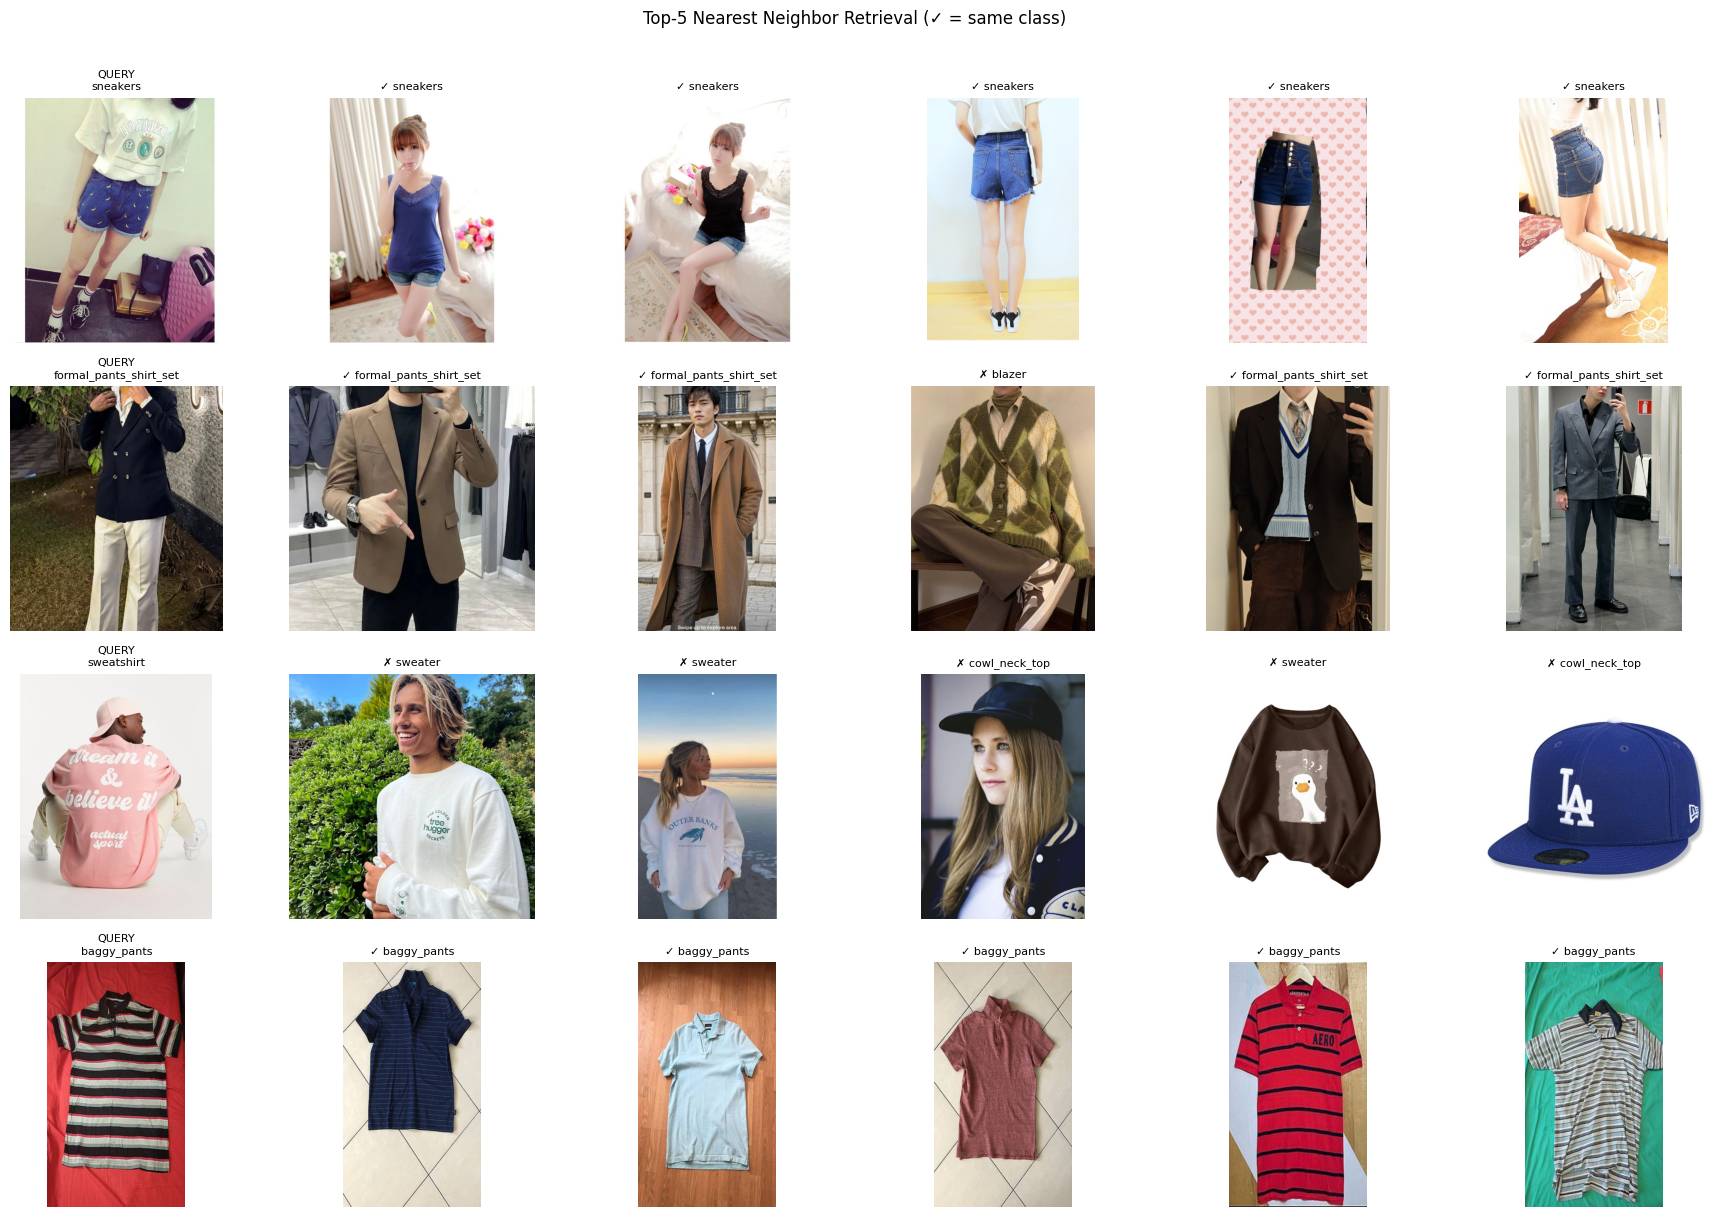

In [18]:
def show_retrieval_batch(embeddings, labels, dataset_samples, n_examples=4, seed=None):
    """Show n_examples query images, each with their top-5 nearest neighbors."""
    rng = random.Random(seed)
    query_indices = rng.sample(range(len(dataset_samples)), n_examples)

    sim = embeddings @ embeddings.t()
    sim.fill_diagonal_(float("-inf"))

    fig, axes = plt.subplots(n_examples, 6, figsize=(18, 3 * n_examples))
    fig.suptitle("Top-5 Nearest Neighbor Retrieval (✓ = same class)", y=1.01)

    for row, q_idx in enumerate(query_indices):
        top5 = sim[q_idx].topk(5).indices.tolist()

        q_path, q_label = dataset_samples[q_idx]
        axes[row, 0].imshow(Image.open(q_path))
        axes[row, 0].set_title(f"QUERY\n{CLASS_NAMES.get(q_label, q_label)}", fontsize=8)
        axes[row, 0].axis("off")

        for col, idx in enumerate(top5):
            path, lbl = dataset_samples[idx]
            axes[row, col + 1].imshow(Image.open(path))
            match = "✓" if lbl == q_label else "✗"
            axes[row, col + 1].set_title(f"{match} {CLASS_NAMES.get(lbl, lbl)}", fontsize=8)
            axes[row, col + 1].axis("off")

    plt.tight_layout()
    plt.show()


show_retrieval_batch(test_emb, test_labels, test_samples, n_examples=4)
